# Attacker-Defender Game Theory

Security is fundamentally adversarial. Unlike floods or earthquakes, attackers
observe your defenses and adapt. A firewall rule that blocks 99% of today's
traffic tells you nothing about tomorrow's attacker who has already read your
vendor's documentation.

Game theory gives us a language for this: two players, each choosing strategies,
each aware that the other is choosing too. This notebook introduces the basics
through security scenarios -- how attackers pick targets, how defenders allocate
budgets, and why the Nash equilibrium is the only defensible resting point for
security investment.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

from decision_security.synth import make_rng, sample
from decision_security.montecarlo import simulate_aggregate_losses, make_lognormal_severity

rng = make_rng(42)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PRIMARY = "#1A1A1A"
ACCENT = "#E74C3C"
DARK_BG = "#34495E"
LIGHT_GRAY = "#95A5A6"

## 1. The Security Game

Start with the simplest possible model. A defender allocates budget across three
attack surfaces -- **network**, **endpoint**, and **application**. An attacker
picks one surface to target.

The payoff rule is deliberately stark:
- If the defender invested in the surface the attacker targets, the loss is low: **$100K**.
- If not, the loss is high: **$1M**.

This gives us a 3x3 payoff matrix (from the defender's perspective, losses are
negative).

Payoff matrix (defender loss, $K):
                     Attack Network  Attack Endpoint  Attack Application
Defender \ Attacker                                                     
Defend Network               -100.0          -1000.0             -1000.0
Defend Endpoint             -1000.0           -100.0             -1000.0
Defend Application          -1000.0          -1000.0              -100.0



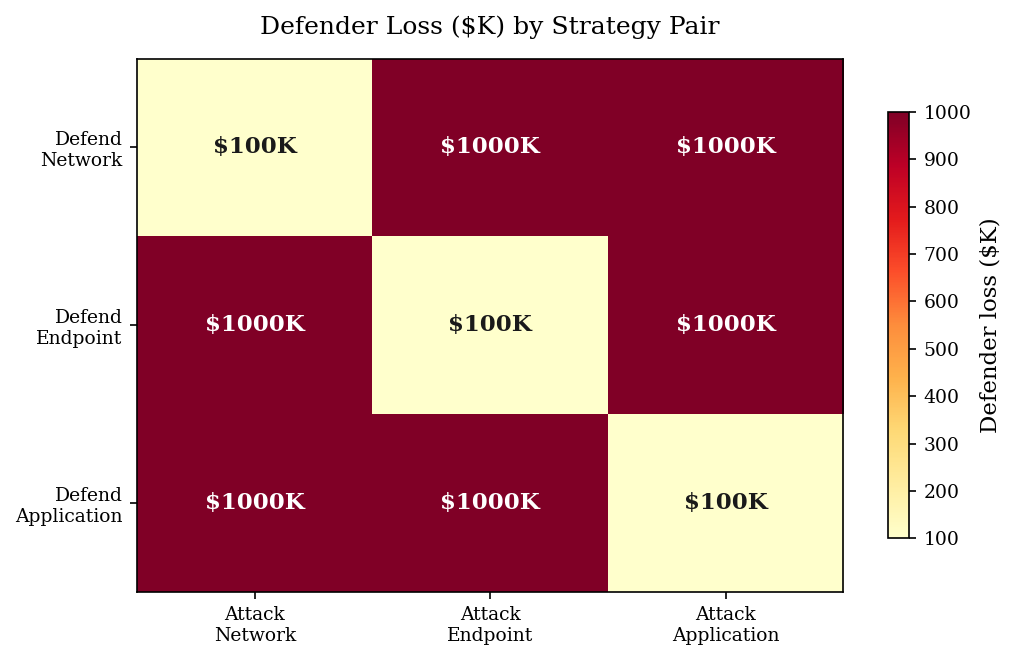

In [2]:
# --- Payoff matrix: Defender loss (negative = bad for defender) ---
surfaces = ["Network", "Endpoint", "Application"]
low_loss = -100_000   # defender invested in this surface
high_loss = -1_000_000  # defender did NOT invest

# Rows = defender strategy (which surface to protect)
# Cols = attacker strategy (which surface to attack)
payoff = np.full((3, 3), high_loss, dtype=float)
np.fill_diagonal(payoff, low_loss)

payoff_df = pd.DataFrame(
    payoff / 1000,
    index=[f"Defend {s}" for s in surfaces],
    columns=[f"Attack {s}" for s in surfaces],
)
payoff_df.index.name = "Defender \\ Attacker"

print("Payoff matrix (defender loss, $K):")
print(payoff_df.to_string())
print()

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(-payoff / 1000, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(3))
ax.set_xticklabels([f"Attack\n{s}" for s in surfaces])
ax.set_yticks(range(3))
ax.set_yticklabels([f"Defend\n{s}" for s in surfaces])
ax.set_title("Defender Loss ($K) by Strategy Pair", pad=12)

for i in range(3):
    for j in range(3):
        val = -payoff[i, j] / 1000
        ax.text(j, i, f"${val:.0f}K", ha="center", va="center",
                fontsize=11, fontweight="bold",
                color="white" if val > 500 else PRIMARY)

# Restore spines for the heatmap
for spine in ax.spines.values():
    spine.set_visible(True)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Defender loss ($K)")
plt.tight_layout()
plt.show()

In [3]:
# --- Pure strategy analysis ---
# No pure-strategy Nash equilibrium exists in symmetric games like this.
# Whatever surface the defender picks, the attacker prefers a different one.
# Whatever surface the attacker picks, the defender wants to match it.

print("Pure strategy check:")
print("="*55)
for d_idx, d_name in enumerate(surfaces):
    # Attacker best-responds: pick the surface with the highest loss for defender
    a_best = np.argmin(payoff[d_idx, :])  # most negative = worst for defender
    # Defender best-responds to that attack
    d_best = np.argmax(payoff[:, a_best])  # least negative = best for defender
    stable = "STABLE" if d_best == d_idx else "EXPLOITABLE"
    print(f"Defender protects {d_name:12s} -> "
          f"Attacker targets {surfaces[a_best]:12s} -> "
          f"Defender should switch to {surfaces[d_best]:12s}  [{stable}]")

print()
print("No pure-strategy Nash equilibrium: every fixed defense is exploitable.")

# --- Mixed strategy Nash equilibrium ---
# In this symmetric game, the mixed-strategy NE has both players
# randomizing uniformly: each surface with probability 1/3.
mixed_def = np.array([1/3, 1/3, 1/3])
mixed_atk = np.array([1/3, 1/3, 1/3])

# Expected loss under mixed strategy
expected_loss_mixed = mixed_def @ payoff @ mixed_atk

# Expected loss under fixed strategy (defend Network, attacker knows)
# Attacker picks Endpoint or Application (either gives -1M)
expected_loss_fixed = high_loss  # attacker just avoids the defended surface

print(f"\nMixed-strategy NE: defend each surface with p = 1/3")
print(f"Expected loss under mixed strategy:  ${-expected_loss_mixed:,.0f}")
print(f"Expected loss under fixed strategy:  ${-expected_loss_fixed:,.0f}")
print(f"\nA predictable defender loses {-expected_loss_fixed/-expected_loss_mixed:.1f}x "
      f"more than one who randomizes.")

Pure strategy check:
Defender protects Network      -> Attacker targets Endpoint     -> Defender should switch to Endpoint      [EXPLOITABLE]
Defender protects Endpoint     -> Attacker targets Network      -> Defender should switch to Network       [EXPLOITABLE]
Defender protects Application  -> Attacker targets Network      -> Defender should switch to Network       [EXPLOITABLE]

No pure-strategy Nash equilibrium: every fixed defense is exploitable.

Mixed-strategy NE: defend each surface with p = 1/3
Expected loss under mixed strategy:  $700,000
Expected loss under fixed strategy:  $1,000,000

A predictable defender loses 1.4x more than one who randomizes.


The key insight: **any fixed, predictable defense is exploitable.** The
attacker simply avoids the defended surface. The only unexploitable strategy
is to randomize -- and randomize in the right proportions.

In the symmetric case above, uniform randomization is optimal. In practice,
surfaces have different values at risk, which changes the equilibrium
probabilities.

## 2. Budget Allocation as a Colonel Blotto Game

The Colonel Blotto game models resource allocation across multiple
battlefields. Whoever spends more on a given battlefield wins it.

Our version:
- **Defender** has **$300K** to allocate across 3 battlefields: perimeter,
  detection, response.
- **Attacker** has **$300K** to allocate across the same 3 battlefields.
- The side that outspends the other on a battlefield wins it.
- Defender "wins" if they win at least 2 of 3 battlefields.

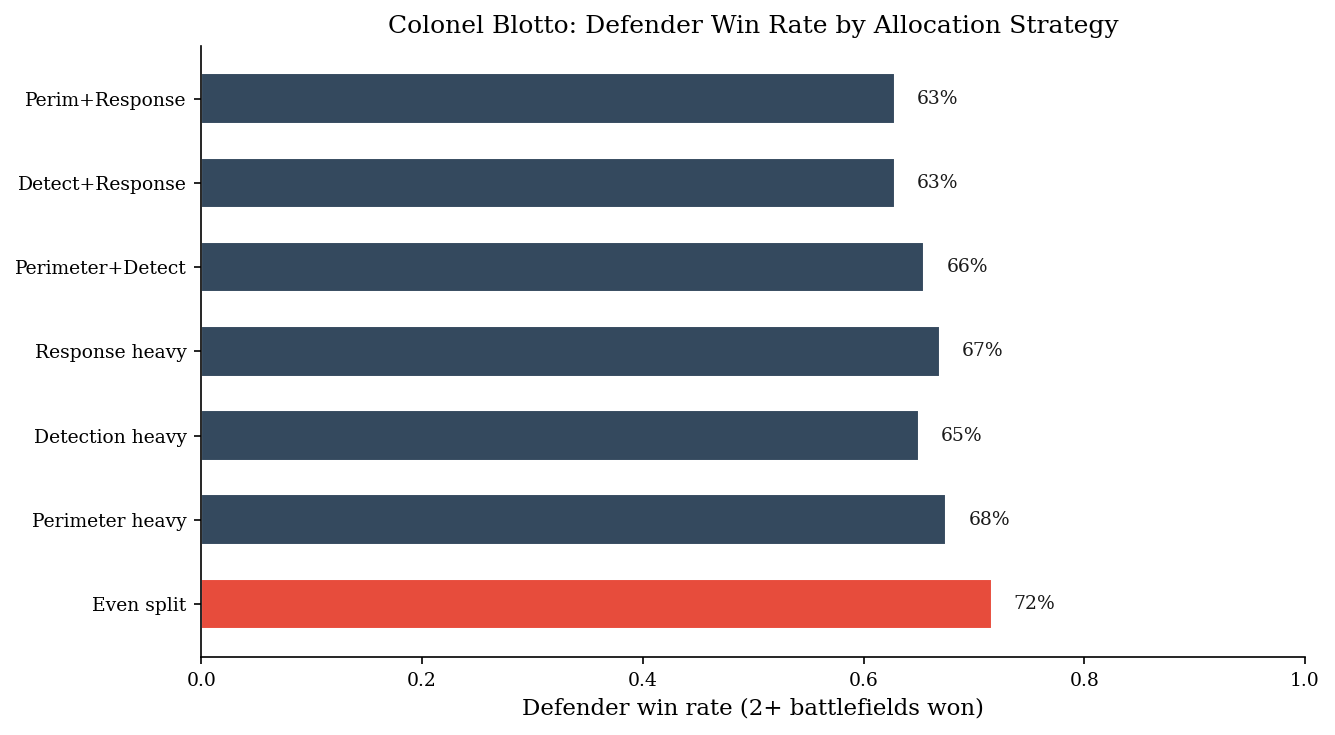

Best strategy: Even split (72% win rate)
Even split:    72% win rate

Concentrating on two battlefields (accepting one loss) tends to
outperform both even spreading and single-field concentration.
Going all-in on one field leaves the other two undefended.


In [4]:
# --- Colonel Blotto: Defender vs Attacker ---

battlefields = ["Perimeter", "Detection", "Response"]
def_budget = 300_000
atk_budget = 300_000

# Defender allocation strategies (must sum to 300K)
def_strategies = {
    "Even split":       np.array([100, 100, 100]) * 1000,
    "Perimeter heavy":  np.array([200, 50, 50]) * 1000,
    "Detection heavy":  np.array([50, 200, 50]) * 1000,
    "Response heavy":   np.array([50, 50, 200]) * 1000,
    "Perimeter+Detect": np.array([140, 140, 20]) * 1000,
    "Detect+Response":  np.array([20, 140, 140]) * 1000,
    "Perim+Response":   np.array([140, 20, 140]) * 1000,
}

def blotto_outcome(defender_alloc, attacker_alloc):
    """Returns number of battlefields won by defender."""
    wins = np.sum(defender_alloc > attacker_alloc)
    ties = np.sum(defender_alloc == attacker_alloc)
    return wins + 0.5 * ties  # ties count as half

def random_attacker_alloc(budget, n_fields, rng):
    """Random allocation: Dirichlet draw with concentration bias."""
    # Attackers tend to concentrate: use low alpha for spiky allocations
    alpha = rng.choice([
        np.array([5.0, 0.5, 0.5]),  # concentrate on perimeter
        np.array([0.5, 5.0, 0.5]),  # concentrate on detection
        np.array([0.5, 0.5, 5.0]),  # concentrate on response
        np.array([3.0, 3.0, 0.5]),  # split two fields
        np.array([0.5, 3.0, 3.0]),
        np.array([3.0, 0.5, 3.0]),
        np.array([1.0, 1.0, 1.0]),  # spread evenly
    ])
    fracs = rng.dirichlet(alpha)
    return fracs * budget

# --- Simulate 1000 rounds ---
n_rounds = 1000
results = {}

for name, d_alloc in def_strategies.items():
    wins = 0
    for _ in range(n_rounds):
        a_alloc = random_attacker_alloc(atk_budget, 3, rng)
        bf_won = blotto_outcome(d_alloc, a_alloc)
        if bf_won >= 2:
            wins += 1
    results[name] = wins / n_rounds

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(9, 5))
strats = list(results.keys())
rates = [results[s] for s in strats]
colors = [ACCENT if r == max(rates) else DARK_BG for r in rates]

bars = ax.barh(range(len(strats)), rates, color=colors, edgecolor="white", height=0.6)
ax.set_yticks(range(len(strats)))
ax.set_yticklabels(strats)
ax.set_xlabel("Defender win rate (2+ battlefields won)")
ax.set_title("Colonel Blotto: Defender Win Rate by Allocation Strategy")
ax.set_xlim(0, 1)

for i, (bar, rate) in enumerate(zip(bars, rates)):
    ax.text(rate + 0.02, i, f"{rate:.0%}", va="center", fontsize=9, color=PRIMARY)

plt.tight_layout()
plt.show()

best = strats[np.argmax(rates)]
print(f"Best strategy: {best} ({max(rates):.0%} win rate)")
print(f"Even split:    {results['Even split']:.0%} win rate")
print()
print("Concentrating on two battlefields (accepting one loss) tends to")
print("outperform both even spreading and single-field concentration.")
print("Going all-in on one field leaves the other two undefended.")

The Blotto game captures a real security tension: you can't be strong
everywhere. With equal budgets, neither side has an inherent advantage --
the outcome depends entirely on allocation strategy.

The optimal defender strategy is **not** to spread evenly. Concentrating on
two of three battlefields -- accepting that the third is a loss -- often
outperforms uniform spreading because it guarantees winning the two you
commit to, while the even split can be beaten by a concentrated attacker.

## 3. Moving Target Defense

If the defender plays a fixed strategy, the attacker eventually learns it
and optimizes against it. A **moving target defense** randomizes the
defender's posture, denying the attacker a stable target to exploit.

We simulate 500 rounds of the Section 1 game:
- **Rounds 1-250:** Defender always protects Network (fixed strategy).
  The attacker learns this after a few rounds and exploits it.
- **Rounds 251-500:** Defender randomizes uniformly across surfaces
  (mixed strategy). The attacker can't predict.

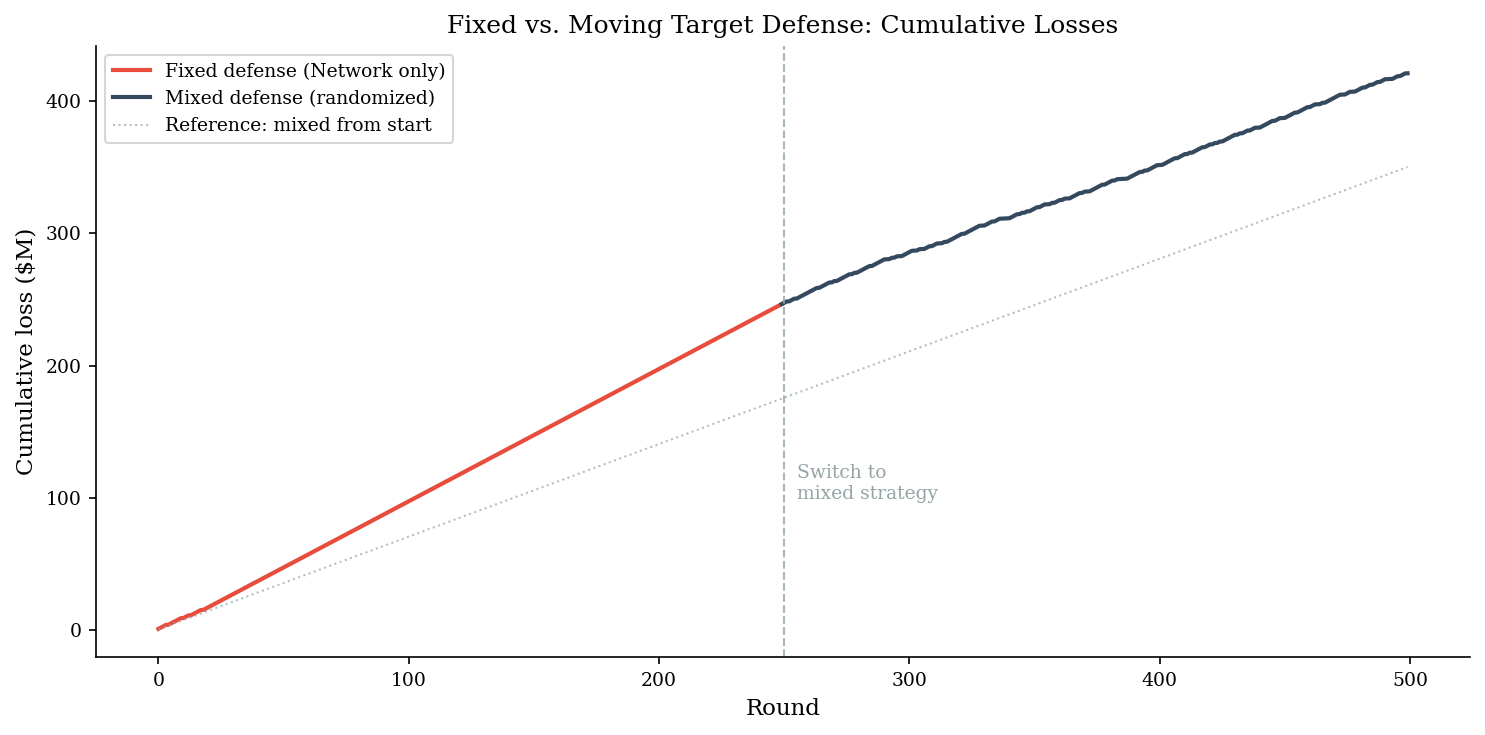

Average loss per round (fixed phase):  $985,600
Average loss per round (mixed phase):  $697,600
Reduction from randomization:          29%


In [5]:
# --- Moving Target Defense Simulation ---
n_rounds = 500
switch_point = 250

losses_fixed = []
losses_mixed = []
cumulative = np.zeros(n_rounds)

rng_sim = make_rng(99)

for r in range(n_rounds):
    if r < switch_point:
        # Fixed strategy: always defend Network (index 0)
        defender_choice = 0
        # Adaptive attacker: first 20 rounds explores, then exploits
        if r < 20:
            attacker_choice = rng_sim.integers(0, 3)
        else:
            # Learned that defender always picks Network -> attack elsewhere
            attacker_choice = rng_sim.choice([1, 2])
    else:
        # Mixed strategy: defender randomizes
        defender_choice = rng_sim.integers(0, 3)
        # Attacker can't predict -> picks randomly too (best they can do)
        attacker_choice = rng_sim.integers(0, 3)

    if defender_choice == attacker_choice:
        loss = 100_000  # defended surface was attacked
    else:
        loss = 1_000_000  # undefended surface was attacked

    cumulative[r] = (cumulative[r-1] if r > 0 else 0) + loss

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

rounds = np.arange(n_rounds)
ax.plot(rounds[:switch_point], cumulative[:switch_point] / 1e6,
        color=ACCENT, lw=2, label="Fixed defense (Network only)")
ax.plot(rounds[switch_point-1:], cumulative[switch_point-1:] / 1e6,
        color=DARK_BG, lw=2, label="Mixed defense (randomized)")

ax.axvline(switch_point, color=LIGHT_GRAY, ls="--", lw=1, alpha=0.8)
ax.text(switch_point + 5, cumulative[switch_point] / 1e6 * 0.4,
        "Switch to\nmixed strategy", fontsize=9, color=LIGHT_GRAY)

# Reference line: what cumulative loss would look like if mixed from start
avg_loss_mixed = (1/3) * 100_000 + (2/3) * 1_000_000  # expected per-round
reference_line = np.cumsum(np.full(n_rounds, avg_loss_mixed)) / 1e6
ax.plot(rounds, reference_line, color=LIGHT_GRAY, ls=":", lw=1,
        label=f"Reference: mixed from start", alpha=0.7)

ax.set_xlabel("Round")
ax.set_ylabel("Cumulative loss ($M)")
ax.set_title("Fixed vs. Moving Target Defense: Cumulative Losses")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

avg_per_round_fixed = np.mean(np.diff(np.concatenate([[0], cumulative[:switch_point]])))
avg_per_round_mixed = np.mean(np.diff(np.concatenate([[cumulative[switch_point-1]], cumulative[switch_point:]])))

print(f"Average loss per round (fixed phase):  ${avg_per_round_fixed:,.0f}")
print(f"Average loss per round (mixed phase):  ${avg_per_round_mixed:,.0f}")
print(f"Reduction from randomization:          {1 - avg_per_round_mixed/avg_per_round_fixed:.0%}")

The slope of the cumulative-loss curve tells the story. Under fixed defense,
the attacker quickly learns the pattern and the slope steepens to nearly
$1M/round. After switching to a mixed strategy, the slope flattens --
the attacker is guessing, and one-third of the time they hit a defended
surface.

This is the operational argument for randomized security controls:
rotating honeypot placements, varying patrol schedules, randomizing
network address layouts.

## 4. Asymmetric Information

Real security games involve uncertainty on both sides. The attacker doesn't
know the defender's exact controls. The defender doesn't know the attacker's
sophistication. Game theory handles this through **Bayesian games**, where
each player has a type drawn from a known distribution.

Consider a single interaction: an attacker decides how aggressively to
target an organization. The attacker can **probe** (low effort, low
payoff) or **commit** (high effort, high payoff if the target is weak).

- If the target is **well-resourced**, a committed attack still fails and the
  attacker wastes effort.
- If the target is **under-resourced**, a committed attack succeeds for a
  large payoff.

The key question: does the attacker know the defender's type?

In [6]:
# --- Bayesian Game: Asymmetric Information ---

# Defender types (unknown to attacker)
def_types = ["Well-resourced", "Under-resourced"]
p_well = 0.7  # 70% of orgs are well-resourced

# Attacker strategies
atk_strats = ["Probe", "Commit"]

# Defender loss matrix: rows = defender type, cols = attacker strategy
# If attacker probes: low-effort scan, modest damage regardless of defenses
# If attacker commits: serious attack -- blocked by strong defenses, devastating to weak
loss_if_probe = np.array([50_000, 200_000])      # [well-resourced, under-resourced]
loss_if_commit = np.array([80_000, 2_000_000])   # [well-resourced, under-resourced]

loss_matrix = np.column_stack([loss_if_probe, loss_if_commit])

# Attacker payoff: gain from attack minus effort cost
# Probe costs $20K effort; Commit costs $200K effort
# Attacker "gain" = fraction of defender loss (simplified: 20% of defender loss)
atk_gain_frac = 0.20
probe_cost = 20_000
commit_cost = 200_000

atk_payoff = np.column_stack([
    loss_if_probe * atk_gain_frac - probe_cost,    # probe payoff
    loss_if_commit * atk_gain_frac - commit_cost,   # commit payoff
])

print("Defender loss by scenario:")
print("="*55)
loss_df = pd.DataFrame(
    loss_matrix,
    index=def_types,
    columns=atk_strats,
)
print(loss_df.map(lambda x: f"${x:,.0f}").to_string())
print()

print("Attacker payoff by scenario (gain - effort cost):")
print("="*55)
atk_df = pd.DataFrame(
    atk_payoff,
    index=[f"vs {t}" for t in def_types],
    columns=atk_strats,
)
print(atk_df.map(lambda x: f"${x:,.0f}").to_string())
print()

# --- With perfect information ---
# Attacker knows the defender type and picks optimally:
atk_choice_perfect = [np.argmax(atk_payoff[i]) for i in range(2)]
loss_perfect = np.array([loss_matrix[i, atk_choice_perfect[i]] for i in range(2)])
expected_loss_perfect = p_well * loss_perfect[0] + (1 - p_well) * loss_perfect[1]

print("With perfect information:")
for i, dt in enumerate(def_types):
    chosen = atk_strats[atk_choice_perfect[i]]
    print(f"  vs {dt}: attacker chooses '{chosen}' "
          f"(payoff ${atk_payoff[i, atk_choice_perfect[i]]:,.0f}) "
          f"-> defender loss ${loss_matrix[i, atk_choice_perfect[i]]:,.0f}")

# --- Without information ---
# Attacker must choose one strategy for ALL targets (doesn't know type).
# Expected attacker payoff for each strategy:
exp_atk_probe = p_well * atk_payoff[0, 0] + (1 - p_well) * atk_payoff[1, 0]
exp_atk_commit = p_well * atk_payoff[0, 1] + (1 - p_well) * atk_payoff[1, 1]

# Rational attacker picks the higher expected payoff
if exp_atk_probe >= exp_atk_commit:
    atk_choice_uncertain = 0
else:
    atk_choice_uncertain = 1

expected_loss_uncertain = (
    p_well * loss_matrix[0, atk_choice_uncertain]
    + (1 - p_well) * loss_matrix[1, atk_choice_uncertain]
)

print(f"\nWithout information:")
print(f"  Expected attacker payoff from Probe:  ${exp_atk_probe:,.0f}")
print(f"  Expected attacker payoff from Commit: ${exp_atk_commit:,.0f}")
print(f"  Rational choice: '{atk_strats[atk_choice_uncertain]}'")
print(f"\nExpected defender loss (perfect info):   ${expected_loss_perfect:,.0f}")
print(f"Expected defender loss (uncertain):      ${expected_loss_uncertain:,.0f}")
info_advantage = expected_loss_perfect - expected_loss_uncertain
print(f"Defender's information advantage:         ${info_advantage:,.0f}")
if info_advantage > 0:
    print(f"  -> Defender saves ${info_advantage:,.0f} when attacker lacks intelligence")

Defender loss by scenario:
                    Probe      Commit
Well-resourced    $50,000     $80,000
Under-resourced  $200,000  $2,000,000

Attacker payoff by scenario (gain - effort cost):
                       Probe     Commit
vs Well-resourced   $-10,000  $-184,000
vs Under-resourced   $20,000   $200,000

With perfect information:
  vs Well-resourced: attacker chooses 'Probe' (payoff $-10,000) -> defender loss $50,000
  vs Under-resourced: attacker chooses 'Commit' (payoff $200,000) -> defender loss $2,000,000

Without information:
  Expected attacker payoff from Probe:  $-1,000
  Expected attacker payoff from Commit: $-68,800
  Rational choice: 'Probe'

Expected defender loss (perfect info):   $635,000
Expected defender loss (uncertain):      $95,000
Defender's information advantage:         $540,000
  -> Defender saves $540,000 when attacker lacks intelligence


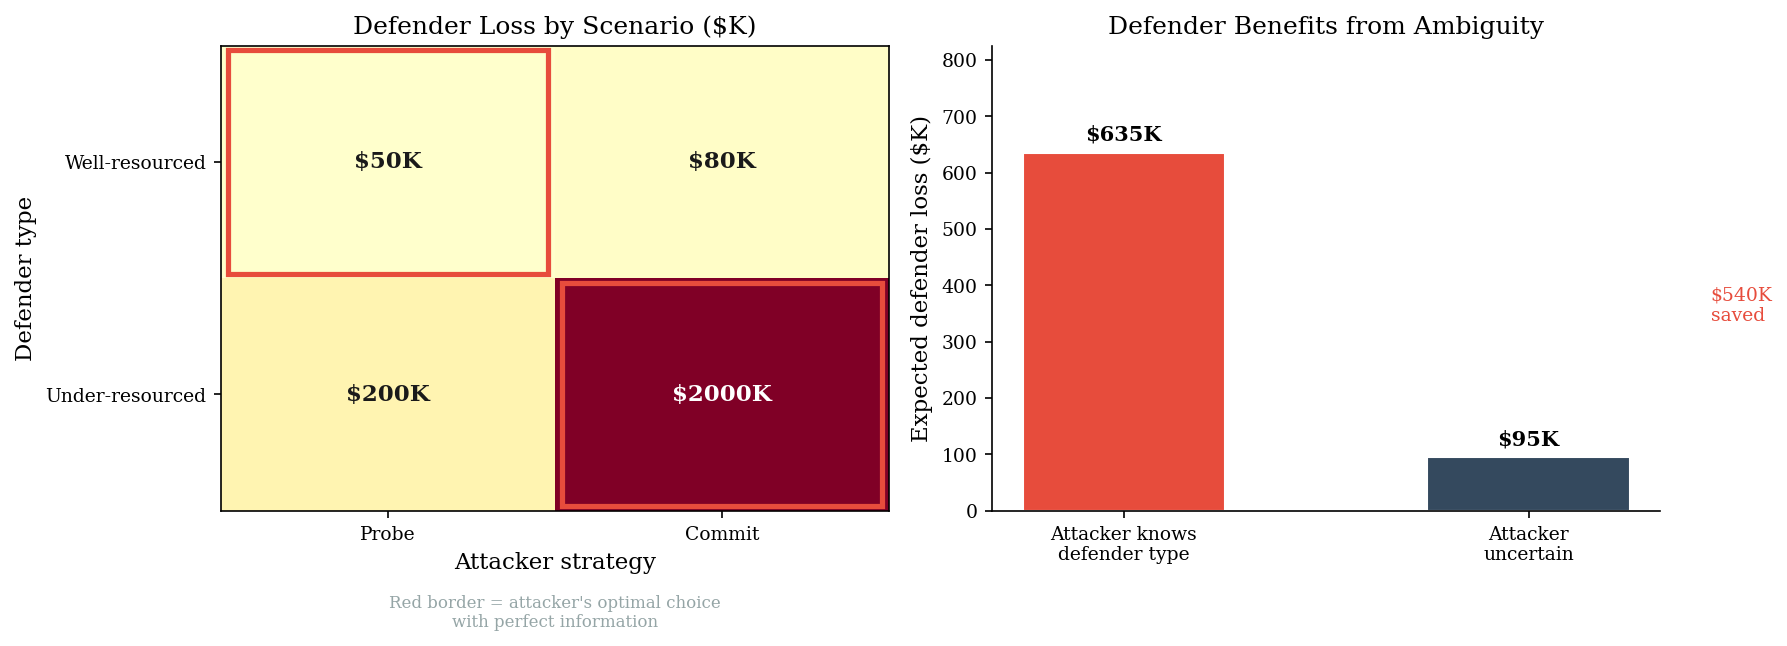


When the attacker knows the defender's type, they calibrate effort:
probe the strong (cheap, low payoff) and commit against the weak
(expensive, high payoff). Under-resourced orgs bear the brunt.

When the attacker is uncertain, they must apply a one-size-fits-all
strategy. This is the information-theoretic argument for not
disclosing your exact security posture.


In [7]:
# --- Visualize the information advantage ---

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: Defender loss heatmap
ax = axes[0]
im = ax.imshow(loss_matrix / 1000, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(2))
ax.set_xticklabels(atk_strats)
ax.set_yticks(range(2))
ax.set_yticklabels(def_types)
ax.set_title("Defender Loss by Scenario ($K)")
ax.set_xlabel("Attacker strategy")
ax.set_ylabel("Defender type")
for spine in ax.spines.values():
    spine.set_visible(True)

for i in range(2):
    for j in range(2):
        val = loss_matrix[i, j] / 1000
        # Highlight the attacker's optimal choice with perfect info
        is_chosen = (j == atk_choice_perfect[i])
        ax.text(j, i, f"${val:.0f}K", ha="center", va="center",
                fontsize=11, fontweight="bold",
                color="white" if val > 500 else PRIMARY)
        if is_chosen:
            from matplotlib.patches import Rectangle
            rect = Rectangle((j - 0.48, i - 0.48), 0.96, 0.96,
                              linewidth=2.5, edgecolor=ACCENT,
                              facecolor="none", linestyle="-")
            ax.add_patch(rect)

ax.text(0.5, -0.25, "Red border = attacker's optimal choice\nwith perfect information",
        transform=ax.transAxes, ha="center", fontsize=8, color=LIGHT_GRAY)

# Right: Information advantage bar chart
ax = axes[1]
scenarios = ["Attacker knows\ndefender type", "Attacker\nuncertain"]
losses = [expected_loss_perfect / 1000, expected_loss_uncertain / 1000]
colors_bar = [ACCENT, DARK_BG]
bars = ax.bar(scenarios, losses, color=colors_bar, width=0.5, edgecolor="white")

for bar, val in zip(bars, losses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f"${val:.0f}K", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Expected defender loss ($K)")
ax.set_title("Defender Benefits from Ambiguity")
ax.set_ylim(0, max(losses) * 1.3)

# Annotate the gap
if losses[0] != losses[1]:
    gap = losses[0] - losses[1]
    mid_y = (losses[0] + losses[1]) / 2
    ax.annotate("", xy=(1.35, losses[1]), xytext=(1.35, losses[0]),
                arrowprops=dict(arrowstyle="<->", color=ACCENT, lw=1.5))
    ax.text(1.45, mid_y, f"${abs(gap):.0f}K\nsaved", fontsize=9,
            color=ACCENT, va="center")

plt.tight_layout()
plt.show()

print("\nWhen the attacker knows the defender's type, they calibrate effort:")
print("probe the strong (cheap, low payoff) and commit against the weak")
print("(expensive, high payoff). Under-resourced orgs bear the brunt.")
print("\nWhen the attacker is uncertain, they must apply a one-size-fits-all")
print("strategy. This is the information-theoretic argument for not")
print("disclosing your exact security posture.")

## 5. The Free-Rider Problem in Shared Security

Two organizations share a supply chain. Each independently decides whether
to invest $200K in security. The payoffs depend on what both do:

| | Org B invests | Org B doesn't invest |
|---|---|---|
| **Org A invests** | Both: $200K (invest cost only) | A: $500K, B: $100K |
| **Org A doesn't invest** | A: $100K, B: $500K | Both: $400K |

If both invest, both are protected -- each pays only the $200K investment.
If neither invests, both face $400K in expected breach losses. But if only
one invests, the free-rider gets partial protection from the supply chain
hardening ($100K loss) while the investor still faces $300K in residual
supply chain losses plus the $200K investment ($500K total).

This is a **Prisoner's Dilemma**: each org is individually better off not
investing ($100K free-ride vs $200K invest when partner cooperates;
$400K vs $500K when partner defects), but the joint optimum is mutual
investment.

In [8]:
# --- Free-Rider Problem: Prisoner's Dilemma in Supply Chain Security ---

# Payoff matrix (total cost, negative = bad)
# Prisoner's Dilemma requires: T > R > P > S  (in terms of benefit, or S > P > R > T in cost)
# where T = temptation (free-ride), R = reward (cooperate), P = punishment (both defect),
#       S = sucker (invest while partner defects)
#
# In cost terms:
#   Free-ride while partner invests: $100K  (best: partial protection, no investment)
#   Both invest:                     $200K  (good: full protection, shared cost)
#   Neither invests:                 $400K  (bad: full exposure)
#   Invest while partner defects:    $500K  (worst: pay investment + supply chain loss)

payoff_a = np.array([
    [-200_000, -500_000],    # A invests: [B invests, B doesn't]
    [-100_000, -400_000],    # A doesn't: [B invests, B doesn't]
])

payoff_b = np.array([
    [-200_000, -100_000],    # B payoff: [A invests+B invests, A invests+B doesn't]
    [-500_000, -400_000],    # [A doesn't+B invests, neither]
])

strategies = ["Invest", "Don't invest"]

print("Payoff matrix (total cost to each org):")
print("="*60)
print(f"{'':20s} {'B invests':>15s}  {'B doesnt invest':>15s}")
for i, sa in enumerate(strategies):
    row = []
    for j in range(2):
        row.append(f"A:${-payoff_a[i,j]/1000:.0f}K, B:${-payoff_b[i,j]/1000:.0f}K")
    print(f"A {sa:16s}  {row[0]:>22s}  {row[1]:>22s}")

print()

# --- Find Nash equilibrium ---
# Check: is "Don't invest" dominant for Org A?
print("Dominance check for Org A:")
for j, sb in enumerate(strategies):
    a_invest = payoff_a[0, j]    # payoff if A invests (negative cost)
    a_defect = payoff_a[1, j]    # payoff if A doesn't invest
    better = "Invest" if a_invest > a_defect else "Don't invest"
    print(f"  If B {sb:16s}: A prefers '{better}' "
          f"(${-a_invest/1000:.0f}K vs ${-a_defect/1000:.0f}K)")

ne_cost = -payoff_a[1, 1]
opt_cost = -payoff_a[0, 0]
print()
print("Nash equilibrium: (Don't invest, Don't invest)")
print(f"  NE payoff:     ${ne_cost/1000:.0f}K each")
print(f"  Optimal payoff: ${opt_cost/1000:.0f}K each (both invest)")
print(f"  Social waste:   ${(2*ne_cost - 2*opt_cost)/1000:.0f}K total")

Payoff matrix (total cost to each org):
                           B invests  B doesnt invest
A Invest                  A:$200K, B:$200K        A:$500K, B:$100K
A Don't invest            A:$100K, B:$500K        A:$400K, B:$400K

Dominance check for Org A:
  If B Invest          : A prefers 'Don't invest' ($200K vs $100K)
  If B Don't invest    : A prefers 'Don't invest' ($500K vs $400K)

Nash equilibrium: (Don't invest, Don't invest)
  NE payoff:     $400K each
  Optimal payoff: $200K each (both invest)
  Social waste:   $400K total


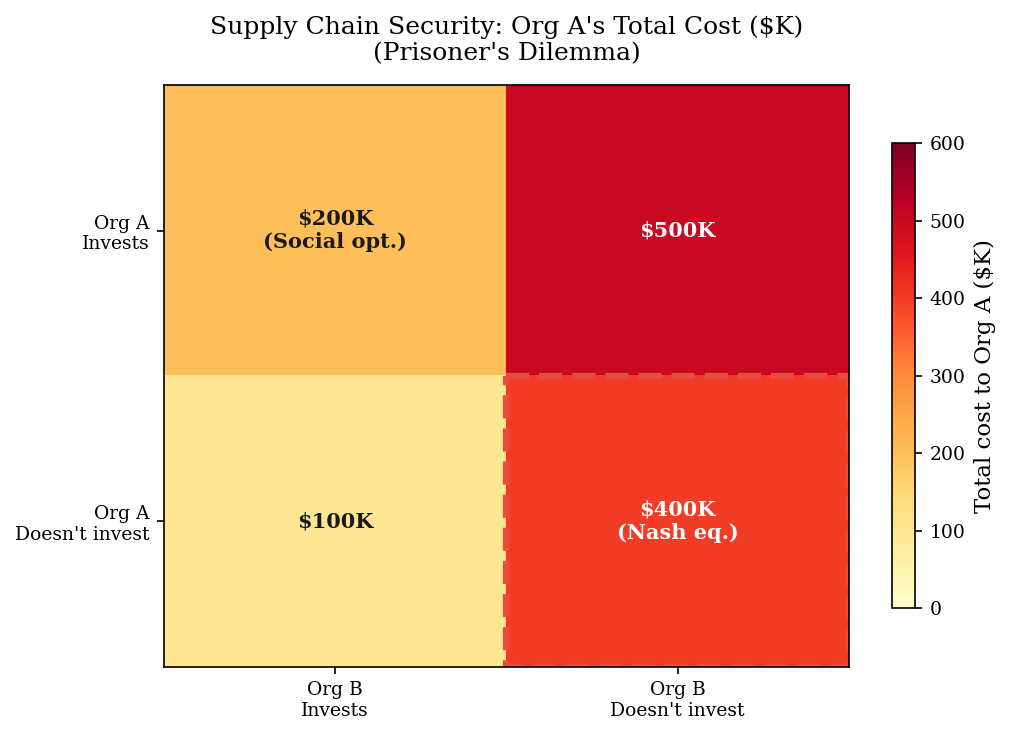

The Nash equilibrium (both defect) costs each org $400K.
The social optimum (both invest) costs each org only $200K.

This $200K gap per organization is why markets alone don't produce
adequate supply chain security. Mechanisms that change the game:
  - Regulatory mandates (DORA, NIS2): make 'don't invest' illegal
  - Information sharing (ISACs): reduce the cost of mutual investment
  - Contract requirements: shift liability to the non-investor
  - Insurance incentives: lower premiums for verified investment


In [9]:
# --- Heatmap with Nash equilibrium highlighted ---

fig, ax = plt.subplots(figsize=(7, 5))

# Display Org A's costs (positive = bad)
costs_a = -payoff_a / 1000

im = ax.imshow(costs_a, cmap="YlOrRd", aspect="auto",
               vmin=0, vmax=600)

ax.set_xticks(range(2))
ax.set_xticklabels([f"Org B\n{s}" for s in ["Invests", "Doesn't invest"]])
ax.set_yticks(range(2))
ax.set_yticklabels([f"Org A\n{s}" for s in ["Invests", "Doesn't invest"]])
ax.set_title("Supply Chain Security: Org A's Total Cost ($K)\n"
             "(Prisoner's Dilemma)", pad=12)

for spine in ax.spines.values():
    spine.set_visible(True)

for i in range(2):
    for j in range(2):
        val = costs_a[i, j]
        # Highlight Nash equilibrium and social optimum
        is_nash = (i == 1 and j == 1)
        is_optimal = (i == 0 and j == 0)
        label = f"${val:.0f}K"
        if is_nash:
            label += "\n(Nash eq.)"
        if is_optimal:
            label += "\n(Social opt.)"
        ax.text(j, i, label, ha="center", va="center",
                fontsize=10, fontweight="bold",
                color="white" if val > 300 else PRIMARY)

# Draw box around Nash equilibrium
from matplotlib.patches import Rectangle
rect = Rectangle((0.5, 0.5), 1, 1, linewidth=3, edgecolor=ACCENT,
                  facecolor="none", linestyle="--")
ax.add_patch(rect)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Total cost to Org A ($K)")

plt.tight_layout()
plt.show()

ne_cost = -payoff_a[1, 1]
opt_cost = -payoff_a[0, 0]
gap = ne_cost - opt_cost

print(f"The Nash equilibrium (both defect) costs each org ${ne_cost/1000:.0f}K.")
print(f"The social optimum (both invest) costs each org only ${opt_cost/1000:.0f}K.")
print()
print(f"This ${gap/1000:.0f}K gap per organization is why markets alone don't produce")
print("adequate supply chain security. Mechanisms that change the game:")
print("  - Regulatory mandates (DORA, NIS2): make 'don't invest' illegal")
print("  - Information sharing (ISACs): reduce the cost of mutual investment")
print("  - Contract requirements: shift liability to the non-investor")
print("  - Insurance incentives: lower premiums for verified investment")

## 6. Pitfalls

**Security is not a game against nature.** Actuarial models treat losses as
draws from a stationary distribution. In security, the distribution shifts
because the attacker is watching your moves.

**Fixed defenses are exploitable by adaptive adversaries.** Any deterministic
defense strategy eventually becomes predictable. The attacker only needs to
observe long enough to learn your pattern.

**The defender's optimal strategy is usually mixed.** Randomization isn't a
sign of indecision -- it's a mathematically optimal response to an adaptive
adversary. This applies to patrol routes, honeypot placement, audit
schedules, and red team targeting.

**Perfect information about your defenses helps the attacker more than it
helps you.** Transparency is a virtue in many domains, but in adversarial
settings, revealing your exact security posture is giving the opponent a
roadmap. The Bayesian game analysis shows that ambiguity is a defender
asset.

**Shared security creates free-rider problems that markets alone don't
solve.** The Prisoner's Dilemma in supply chain security is not a market
failure that will self-correct. It's a structural incentive problem that
requires external mechanisms: regulation, contracts, or insurance.

**The game-theoretic perspective doesn't require knowing the attacker.** It
requires knowing your own attack surfaces, the relative value at risk on
each, and the fact that someone out there is choosing rationally where to
hit. That's usually enough to derive a defensible allocation.